# Actividad 2 — Lectura · INDECI

**Fuentes:**
- `sources/indeci/resumenes/resumen_emergencias_2003_2024.xlsx`
- `sources/indeci/resumenes/resumen_peligros_2003_2024.xlsx`
- `sources/indeci/resumenes/piura_emergencias.xlsx`
- `sources/indeci/resumenes/piura_peligros.xlsx`
- `sources/indeci/shapefiles/E_2021/`, `E_2022/`, `E_2023/`

**Institución:** Instituto Nacional de Defensa Civil (INDECI) — Sistema SINPAD

## Objetivo
Leer todas las fuentes INDECI, identificar su estructura y hacer una primera inspección del contenido **sin modificar nada**.

## Nota sobre NLP
> Los campos de texto libre (descripción de emergencias) se **conservan sin procesar** para la Fase 2 del proyecto (modelo BETO). En esta fase solo se usan variables numéricas y categóricas.


### Configuración inicial
Carga el `pipeline_config.json` generado en la Actividad 1 y las librerías necesarias.


In [1]:
import os, sys, json, glob, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Asegurar raiz del proyecto
while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')

with open('pipeline/config/pipeline_config.json', 'r', encoding='utf-8') as f:
    CONFIG = json.load(f)

SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado correctamente.')
print('Raiz del proyecto:', os.getcwd())


Config cargado correctamente.
Raiz del proyecto: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## 2.1 Lectura de resúmenes Excel


In [2]:
# ============================================================
# 2.1 Lectura de resumenes Excel
# ============================================================
import glob as gl

xlsx_files = gl.glob(SOURCES['indeci_resumenes'] + '*.xlsx')
print(f'Archivos Excel encontrados: {len(xlsx_files)}')
print()

dfs_resumenes = {}
for f in sorted(xlsx_files):
    nombre = os.path.basename(f).replace('.xlsx', '')
    df = pd.read_excel(f, sheet_name=0)
    dfs_resumenes[nombre] = df
    print(f'  {nombre}')
    print(f'    Shape: {df.shape}')
    print(f'    Columnas: {df.columns.tolist()}')
    print()


Archivos Excel encontrados: 4

  piura_emergencias
    Shape: (100, 18)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17']

  piura_peligros
    Shape: (114, 22)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21']

  resumen_emergencias_2003_2024
    Shape: (35, 17)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 1

  resumen_peligros_2003_2024
    Shape: (30, 28)
    Columnas: ['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']



## 2.2 Lectura de shapefiles (DBF)


In [3]:
# ============================================================
# 2.2 Lectura de shapefiles via geopandas
# ============================================================
import geopandas as gpd

shp_dirs = sorted(gl.glob(SOURCES['indeci_shapefiles'] + 'E_*/'))  
print(f'Carpetas shapefile encontradas: {len(shp_dirs)}')
print()

dfs_shp = {}
for d in shp_dirs:
    shp_files = gl.glob(d + '*.shp')
    if shp_files:
        anio = os.path.basename(d.rstrip('/\\'))
        gdf = gpd.read_file(shp_files[0])
        dfs_shp[anio] = gdf
        print(f'  {anio}: {shp_files[0]}')
        print(f'    Shape: {gdf.shape}')
        print(f'    Columnas: {gdf.columns.tolist()}')
        print(f'    CRS: {gdf.crs}')
        print()

# Concatenar shapefiles en un solo DataFrame (sin geometria para analisis tabular)
dfs_shp_list = []
for anio, gdf in dfs_shp.items():
    df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
    df_tmp['anio_shapefile'] = anio
    dfs_shp_list.append(df_tmp)

df_indeci_shp = pd.concat(dfs_shp_list, ignore_index=True) if dfs_shp_list else pd.DataFrame()
print(f'Dataset shapefiles concatenado: {df_indeci_shp.shape}')
display(df_indeci_shp.head(3))


Carpetas shapefile encontradas: 3



  E_2021: sources/indeci/shapefiles\E_2021\Emergencias_2021.shp
    Shape: (11175, 78)
    Columnas: ['ide_sinpad', 'fecha', 'anho', 'mes', 'cod_ubigeo', 'departamen', 'provincia', 'distrito', 'fenomeno', 'region', 'safecta', 'sdamni', 'sfalle', 'slesi', 'sdesa', 'safecmvp', 'safecmvd', 'sdestruviv', 'sinhabiviv', 'safectaviv', 'sccee_afec', 'scee_destr', 'sdestru_au', 'safec_aula', 'sinhab_aul', 'sdestru_sa', 'safecta_sa', 'sinhabi_sa', 'sigle_afec', 'sigle_dest', 'sloccomu_a', 'sloccomu_d', 'slocmuni_a', 'slocmuni_d', 'sestacoli_', 'sestacoli1', 'salber_afe', 'salber_des', 'scamirural', 'scamirur_1', 'scarre_afe', 'scarre_des', 'svferrea_a', 'svferrea_d', 'spuente_af', 'spuente_de', 'stelefija_', 'stelemov_a', 'sinternet_', 'scanal_afe', 'scanal_des', 'sotroscana', 'sotrosca_1', 'sreservo_a', 'sreservo_d', 'saguapota_', 'saguapota1', 'sdesague_a', 'sdesague_d', 'senergia_a', 'senergia_d', 'sareaculti', 'sareacul_1', 'sanimal_af', 'sanimal_pe', 'sanimal__1', 'sanimal__2', 'sanimal__3'

  E_2022: sources/indeci/shapefiles\E_2022\Emergencias_2022.shp
    Shape: (11574, 80)
    Columnas: ['IDE_SINPAD', 'FECHA', 'ANHO', 'MES', 'COD_UBIGEO', 'DEPARTAMEN', 'PROVINCIA', 'DISTRITO', 'ST_TEMP', 'FENOMENO', 'DES_GRUPAL', 'REGION', 'SAFECTA', 'SDAMNI', 'SFALLE', 'SLESI', 'SDESA', 'SAFECMVP', 'SAFECMVD', 'SDESTRUVIV', 'SINHABIVIV', 'SAFECTAVIV', 'SCCEE_AFEC', 'SCEE_DESTR', 'SDESTRU_AU', 'SAFEC_AULA', 'SINHAB_AUL', 'SDESTRU_SA', 'SAFECTA_SA', 'SINHABI_SA', 'SIGLE_AFEC', 'SIGLE_DEST', 'SLOCCOMU_A', 'SLOCCOMU_D', 'SLOCMUNI_A', 'SLOCMUNI_D', 'SESTACOLI_', 'SESTACOLI1', 'SALBER_AFE', 'SALBER_DES', 'SCAMIRURAL', 'SCAMIRUR_1', 'SCARRE_AFE', 'SCARRE_DES', 'SVFERREA_A', 'SVFERREA_D', 'SPUENTE_AF', 'SPUENTE_DE', 'STELEFIJA_', 'STELEMOV_A', 'SINTERNET_', 'SCANAL_AFE', 'SCANAL_DES', 'SOTROSCANA', 'SOTROSCA_1', 'SRESERVO_A', 'SRESERVO_D', 'SAGUAPOTA_', 'SAGUAPOTA1', 'SDESAGUE_A', 'SDESAGUE_D', 'SENERGIA_A', 'SENERGIA_D', 'SAREACULTI', 'SAREACUL_1', 'SANIMAL_AF', 'SANIMAL_PE', 'SANIMAL__1', '

,ide_sinpad,fecha,anho,mes,cod_ubigeo,departamen,provincia,distrito,fenomeno,region,safecta,sdamni,sfalle,slesi,sdesa,safecmvp,safecmvd,sdestruviv,sinhabiviv,safectaviv,sccee_afec,scee_destr,sdestru_au,safec_aula,sinhab_aul,sdestru_sa,safecta_sa,sinhabi_sa,sigle_afec,sigle_dest,sloccomu_a,sloccomu_d,slocmuni_a,slocmuni_d,sestacoli_,sestacoli1,salber_afe,salber_des,scamirural,scamirur_1,scarre_afe,scarre_des,svferrea_a,svferrea_d,spuente_af,spuente_de,stelefija_,stelemov_a,sinternet_,scanal_afe,scanal_des,sotroscana,sotrosca_1,sreservo_a,sreservo_d,saguapota_,saguapota1,sdesague_a,sdesague_d,senergia_a,senergia_d,sareaculti,sareacul_1,sanimal_af,sanimal_pe,sanimal__1,sanimal__2,sanimal__3,sanimal__4,sanimal__5,sanimal__6,sanimal__7,sanimal__8,sanimal__9,sanimal_10,num_posx,num_posy,anio_shapefile,IDE_SINPAD,FECHA,ANHO,MES,COD_UBIGEO,DEPARTAMEN,PROVINCIA,DISTRITO,ST_TEMP,FENOMENO,DES_GRUPAL,REGION,SAFECTA,SDAMNI,SFALLE,SLESI,SDESA,SAFECMVP,SAFECMVD,SDESTRUVIV,SINHABIVIV,SAFECTAVIV,SCCEE_AFEC,SCEE_DESTR,SDESTRU_AU,SAFEC_AULA,SINHAB_AUL,SDESTRU_SA,SAFECTA_SA,SINHABI_SA,SIGLE_AFEC,SIGLE_DEST,SLOCCOMU_A,SLOCCOMU_D,SLOCMUNI_A,SLOCMUNI_D,SESTACOLI_,SESTACOLI1,SALBER_AFE,SALBER_DES,SCAMIRURAL,SCAMIRUR_1,SCARRE_AFE,SCARRE_DES,SVFERREA_A,SVFERREA_D,SPUENTE_AF,SPUENTE_DE,STELEFIJA_,STELEMOV_A,SINTERNET_,SCANAL_AFE,SCANAL_DES,SOTROSCANA,SOTROSCA_1,SRESERVO_A,SRESERVO_D,SAGUAPOTA_,SAGUAPOTA1,SDESAGUE_A,SDESAGUE_D,SENERGIA_A,SENERGIA_D,SAREACULTI,SAREACUL_1,SANIMAL_AF,SANIMAL_PE,SANIMAL__1,SANIMAL__2,SANIMAL__3,SANIMAL__4,SANIMAL__5,SANIMAL__6,SANIMAL__7,SANIMAL__8,SANIMAL__9,SANIMAL_10,NUM_POSX,NUM_POSY,Fecha,Mes,Departamen,Provincia,Distrito,Region
0,132749.0,12/01/2021,2021,ENERO,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,LLUVIAS INTENSAS,SIERRA,3.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-77.8743,-6.22937,E_2021,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
1,135727.0,02/03/2021,2021,MARZO,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,LLUVIAS INTENSAS,SIERRA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-77.8743,-6.22937,E_2021,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
2,137608.0,30/03/2021,2021,MARZO,010101,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,LLUVIAS INTENSAS,SIERRA,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,-77.8743,-6.22937,E_2021,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN


## 2.3 Gráfico 4 — Top 15 fenómenos por frecuencia


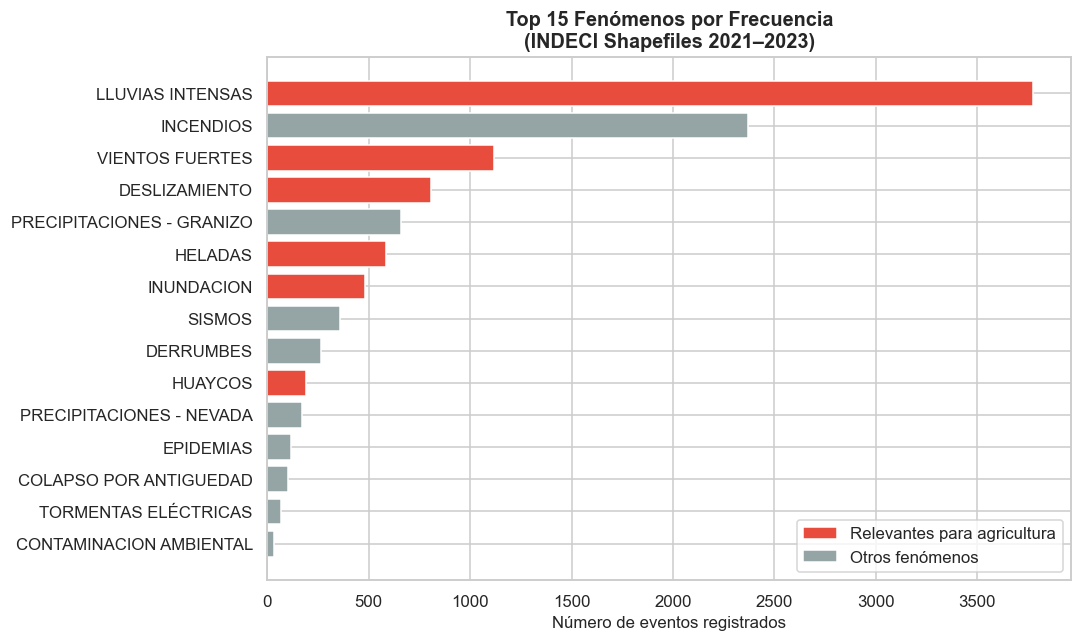

Guardado: pipeline/output/03_eda/indeci_g4_top_fenomenos.png


In [4]:
# ============================================================
# GRAFICO 4: Top fenomenos por frecuencia (shapefiles)
# ============================================================
col_fenomeno = [c for c in df_indeci_shp.columns
                if 'FENOM' in str(c).upper() or 'TIPO' in str(c).upper() or 'PELIGRO' in str(c).upper()]

if col_fenomeno:
    col_f = col_fenomeno[0]
    top_fen = df_indeci_shp[col_f].value_counts().head(15).sort_values(ascending=True)

    # Resaltar fenomenos relevantes para agricultura
    relevantes = ['LLUVIAS INTENSAS','INUNDACION','HUAYCO','SEQUIA',
                  'HELADAS','FRIAJE','VIENTOS FUERTES','DESLIZAMIENTO']
    colors = ['#e74c3c' if any(r in str(c).upper() for r in relevantes)
              else '#95a5a6' for c in top_fen.index]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_fen.index, top_fen.values, color=colors)
    ax.set_xlabel('Número de eventos registrados', fontsize=11)
    ax.set_title('Top 15 Fenómenos por Frecuencia\n(INDECI Shapefiles 2021–2023)', fontsize=13, fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Relevantes para agricultura'),
                       Patch(facecolor='#95a5a6', label='Otros fenómenos')]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    out_g4 = OUTPUT['eda'] + 'indeci_g4_top_fenomenos.png'
    plt.savefig(out_g4, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_g4}')
else:
    print('Columna de fenomeno no encontrada. Columnas disponibles:', df_indeci_shp.columns.tolist())


### Interpretación — Gráfico 4

**Qué muestra:** Los 15 tipos de fenómenos más frecuentes en los registros INDECI 2021–2023. En rojo aparecen los fenómenos hidrometeorológicos relevantes para la agricultura.

**Implicación para el pipeline:** En la Actividad 5 se filtrará el dataset INDECI conservando únicamente los fenómenos marcados en rojo. Los demás (accidentes, incendios urbanos, etc.) no tienen relación causal con la producción agrícola y serían ruido para el modelo.

**Implicación para el modelo:** Los fenómenos hidrometeorológicos son variables exógenas clave para el LSTM-Attention porque representan shocks externos que afectan directamente la cosecha y el precio del limón en el corto plazo.


## 2.4 Gráfico 5 — Emergencias por año


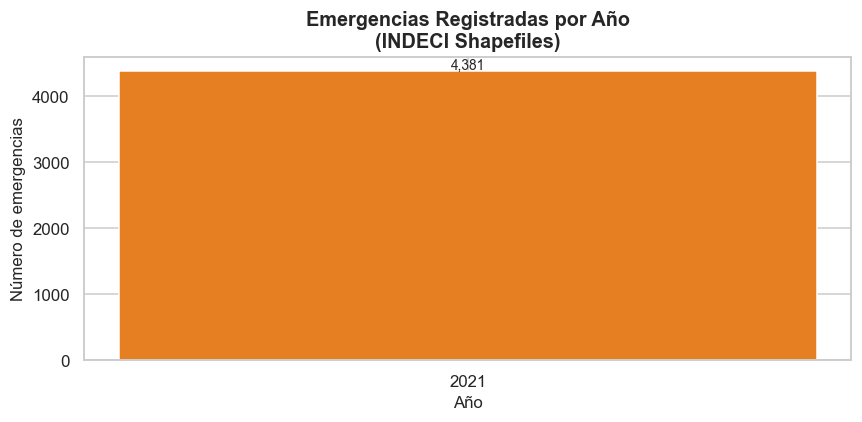

Guardado: pipeline/output/03_eda/indeci_g5_emergencias_anio.png


In [5]:
# ============================================================
# GRAFICO 5: Emergencias por año
# ============================================================
col_fecha = [c for c in df_indeci_shp.columns
             if 'FECHA' in str(c).upper() or 'DATE' in str(c).upper() or 'AÑO' in str(c).upper()]

if col_fecha:
    df_indeci_shp['_fecha_tmp'] = pd.to_datetime(df_indeci_shp[col_fecha[0]], errors='coerce')
    df_indeci_shp['_anio_tmp'] = df_indeci_shp['_fecha_tmp'].dt.year
    por_anio = df_indeci_shp['_anio_tmp'].value_counts().sort_index().dropna()
else:
    por_anio = df_indeci_shp['anio_shapefile'].str.extract(r'(\d{4})')[0].astype(float).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(por_anio.index.astype(int).astype(str), por_anio.values, color='#e67e22', edgecolor='white')
ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('Número de emergencias', fontsize=11)
ax.set_title('Emergencias Registradas por Año\n(INDECI Shapefiles)', fontsize=13, fontweight='bold')
for i, (x, v) in enumerate(zip(por_anio.index, por_anio.values)):
    ax.text(i, v + 20, f'{int(v):,}', ha='center', fontsize=9)
plt.tight_layout()
out_g5 = OUTPUT['eda'] + 'indeci_g5_emergencias_anio.png'
plt.savefig(out_g5, dpi=120, bbox_inches='tight')
plt.show()
print(f'Guardado: {out_g5}')


### Interpretación — Gráfico 5

**Qué muestra:** El número total de emergencias registradas por año en los shapefiles INDECI.

**Implicación para el pipeline:** Un pico en 2023 confirmaría el impacto del Fenómeno del Niño Costero, que es un evento conocido que afectó severamente la producción agrícola en la costa peruana. Este contexto debe documentarse en la tesis como validación externa de los datos.

**Implicación para el modelo:** Los años con más emergencias deberían correlacionar con caídas en la producción de limón. Si esta correlación es visible en los datos, refuerza la justificación de incluir INDECI como variable exógena en el LSTM-Attention.


## 2.5 Gráfico 6 — Top 10 departamentos con más emergencias


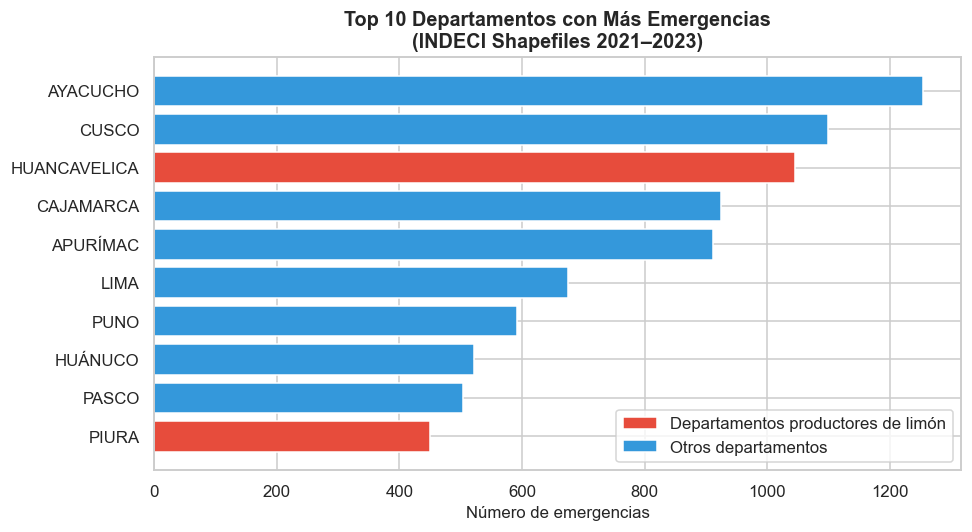

Guardado: pipeline/output/03_eda/indeci_g6_top_departamentos.png


In [6]:
# ============================================================
# GRAFICO 6: Top departamentos con mas emergencias
# ============================================================
col_dpto = [c for c in df_indeci_shp.columns
            if 'DPTO' in str(c).upper() or 'DEPART' in str(c).upper() or 'REGION' in str(c).upper()]

if col_dpto:
    top_dpto = df_indeci_shp[col_dpto[0]].value_counts().head(10).sort_values(ascending=True)

    # Departamentos productores de limon
    limoneros = ['PIURA','LA LIBERTAD','LAMBAYEQUE','ICA','TUMBES']
    colors = ['#e74c3c' if any(l in str(d).upper() for l in limoneros)
              else '#3498db' for d in top_dpto.index]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(top_dpto.index, top_dpto.values, color=colors)
    ax.set_xlabel('Número de emergencias', fontsize=11)
    ax.set_title('Top 10 Departamentos con Más Emergencias\n(INDECI Shapefiles 2021–2023)', fontsize=13, fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Departamentos productores de limón'),
                       Patch(facecolor='#3498db', label='Otros departamentos')]
    ax.legend(handles=legend_elements, loc='lower right')
    plt.tight_layout()
    out_g6 = OUTPUT['eda'] + 'indeci_g6_top_departamentos.png'
    plt.savefig(out_g6, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {out_g6}')
else:
    print('Columna de departamento no encontrada. Columnas:', df_indeci_shp.columns.tolist())


### Interpretación — Gráfico 6

**Qué muestra:** Los 10 departamentos con mayor número de emergencias registradas. En rojo aparecen los principales departamentos productores de limón.

**Implicación para el pipeline:** Si los departamentos limoneros aparecen entre los más afectados, valida que el dataset INDECI tiene cobertura relevante para el cultivo objetivo. Si no aparecen, puede indicar que los shapefiles tienen cobertura geográfica incompleta y se deberá complementar con los resúmenes Excel.

**Implicación para el modelo:** La presencia de departamentos limoneros en el top de emergencias sugiere que la variable `num_emergencias` tendrá variabilidad suficiente para ser informativa en el modelo predictivo.


## 2.6 Exportación del raw


In [7]:
# ============================================================
# 2.6 Exportar CSVs raw
# ============================================================
# Resumen principal (emergencias)
if 'resumen_emergencias_2003_2024' in dfs_resumenes:
    out_res = OUTPUT['lectura'] + 'indeci_resumenes_raw.csv'
    dfs_resumenes['resumen_emergencias_2003_2024'].to_csv(out_res, index=False, encoding='utf-8-sig')
    print(f'Exportado: {out_res}')

# Shapefiles concatenados
if not df_indeci_shp.empty:
    out_shp = OUTPUT['lectura'] + 'indeci_shapefiles_raw.csv'
    df_indeci_shp.to_csv(out_shp, index=False, encoding='utf-8-sig')
    print(f'Exportado: {out_shp}')
    print(f'Shape: {df_indeci_shp.shape}')

print()
print('[ACTIVIDAD 2 - INDECI] COMPLETADA.')
print('  Siguiente paso: pipeline/fuentes/indeci/actividad_03_eda_indeci.ipynb')


Exportado: pipeline/output/02_lectura/indeci_resumenes_raw.csv


Exportado: pipeline/output/02_lectura/indeci_shapefiles_raw.csv
Shape: (25025, 165)

[ACTIVIDAD 2 - INDECI] COMPLETADA.
  Siguiente paso: pipeline/fuentes/indeci/actividad_03_eda_indeci.ipynb
